### Моделирование БИНС карьерного самосвала БелАЗ-7513

In [1]:
if 'autoreload' not in get_ipython().extension_manager.loaded:
    %load_ext autoreload
else:
    %reload_ext autoreload
    
%autoreload 2

# %matplotlib qt5

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORT_DIR = PROJECT_ROOT / 'reports'
DATA_DIR   = PROJECT_ROOT / 'generated_data'
MOTION_DIR   = PROJECT_ROOT / 'motion_profiles'

REPORT_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
MOTION_DIR.mkdir(exist_ok=True)

# Config libs
from src.config.config import IMU_ERR, GPS_ERR
from src.config.constants import FS_IMU, FS_GPS, INIT_LAT, INIT_LON, INIT_ALT, A_WGS84

# Navigation
from src.navigation.ekf import InsGnssEKF
from src.navigation.ukf import InsGnssUKF
from src.navigation.fgo import InsGnssFGO

# Analysis libs

# Visualization libs
from src.analysis.visualization import ( 
	plot_accel_signal, plot_gyro_signal,
	plot_psd, plot_spectrogram_2d, plot_spectrogram_3d,
	plot_allan_simulated,
	plot_trajectory_3d, plot_velocity_ned, plot_euler_angles,
	plot_position_error, plot_attitude_error,
	plot_beta_sweep
)

Шрифт Times New Roman загружен из Windows


Генерация всех профилей движения

In [ ]:
from src.simulation.motion_generator import generate_all

generate_all(out_dir=MOTION_DIR)

Генерируем сценарий -> IMU, GNSS data

In [2]:
from src.analysis.frames import prepare_scenario

# Сценарии: 01_stationary, 02_acceleration, 03_straight_cruise,
#           04_braking, 05_turn, 06_uphill, 07_downhill_turn,
#           10_accel_cruise_brake, 99_full_mission
S = prepare_scenario('02_acceleration', MOTION_DIR, DATA_DIR)


------------------------------------------------------------
Sample frequency of IMU: [fs] = 400.0 Hz
Reference frame: 0
Simulation time duration: 11.1125 s
Simulation runs: 1

------------------------------------------------------------
Simulation results are saved to /home/rsadovec/prj/KAMAZ_Jupyter/generated_data/02_acceleration
The following results are saved:
	time: sample time
	ref_pos: true LLA pos in the navigation frame
	ref_vel: true vel in the NED frame
	ref_att_euler: true attitude (Euler angles, ZYX)
	ref_accel: true accel in the body frame
	ref_gyro: true angular velocity in the body frame
	gps_time: GPS sample time
	ref_gps: true GPS LLA position and NED velocity
	gps_visibility: GPS visibility
	accel: accel measurements
	gyro: gyro measurements
	gps: GPS LLA position and NED velocity measurements
	ref_att_quat: true attitude (quaternion)



In [ ]:
# print("=== Проверка опорного решения ===")
# print(f"ref_pos_ned shape: {ref_pos_ned.shape}")
# print(f"стартовая точка (должна быть ~0,0,0): {ref_pos_ned[0]}")
# print(f"конечная точка:                       {ref_pos_ned[-1]}")
# print(f"длина по North: {ref_pos_ned[-1,0]:.2f} м")
# print(f"длина по East:  {ref_pos_ned[-1,1]:.2f} м (для gen_acceleration ожидаем ~0)")
# print(f"длина по Down:  {ref_pos_ned[-1,2]:.2f} м (ожидаем ~0)")

# # Аналитическая проверка для gen_acceleration: 2,0,0,0,11.11,0,0,20,1
# # Это разгон 0 -> 11.11 м/с за 20 с, ускорение 0.555 м/с^2.
# # Путь за 20с: 0.5*0.555*20^2 = 111.1 м (если симулятор выходит на v=11.11 за всё время)
# # На картинке у вас ~60 м North за 11 с — проверьте, что у вас сцен. длится столько же
# print(f"\nДлительность IMU: {imu_time[-1]:.2f} с, отсчётов: {len(imu_time)}")

# # Линейность скорости (она должна расти линейно при постоянном ускорении)
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
# for i, name in enumerate(['North', 'East', 'Down']):
#     axes[i].plot(imu_time, ref_pos_ned[:,i], label='ref_pos_rs (после интерп.)')
#     axes[i].set_title(f'{name}'); axes[i].legend(); axes[i].grid(True)
# plt.tight_layout(); plt.show()

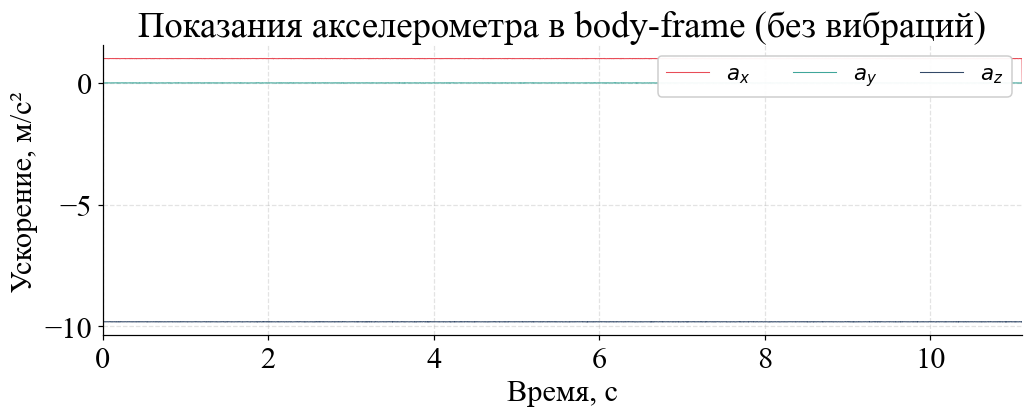

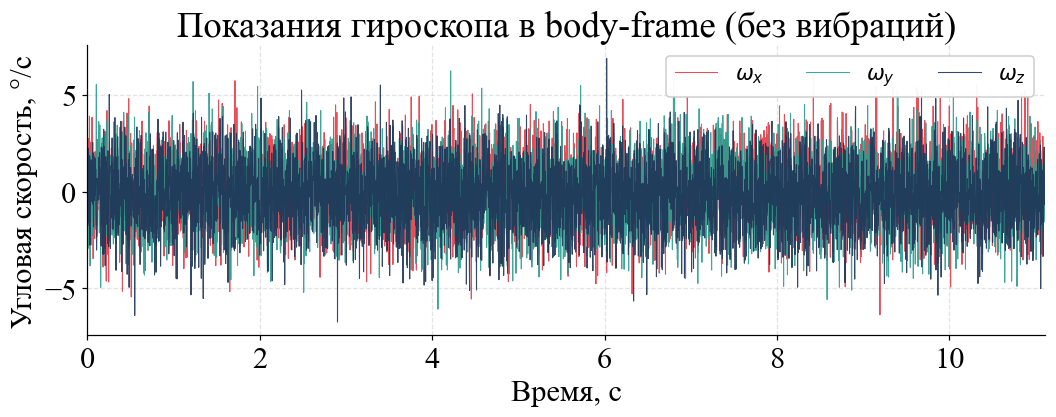

In [ ]:
plot_accel_signal(S['imu_time'], S['accel'], ' (без вибраций)',
                  save_dir=f'{REPORT_DIR}/raw')
_ = plot_gyro_signal(S['imu_time'], S['gyro'], ' (без вибраций)',
                 save_dir=f'{REPORT_DIR}/raw')

# plot_accel_signal(S['imu_time'], S['accel_vib'], ' (с вибрациями ДВС)',
#                   save_dir=f'{REPORT_DIR}/with_vib')
# _ = plot_gyro_signal(S['imu_time'], S['gyro_vib'], ' (с вибрациями ДВС)',
#                  save_dir=f'{REPORT_DIR}/with_vib')

/home/rsadovec/prj/KAMAZ_Jupyter/src/analysis/visualization.py:124: UserWarning: nperseg=8192 is greater than signal length max(len(x), len(y)) = 4445, using nperseg = 4445
  f, Pxx = signal.welch(


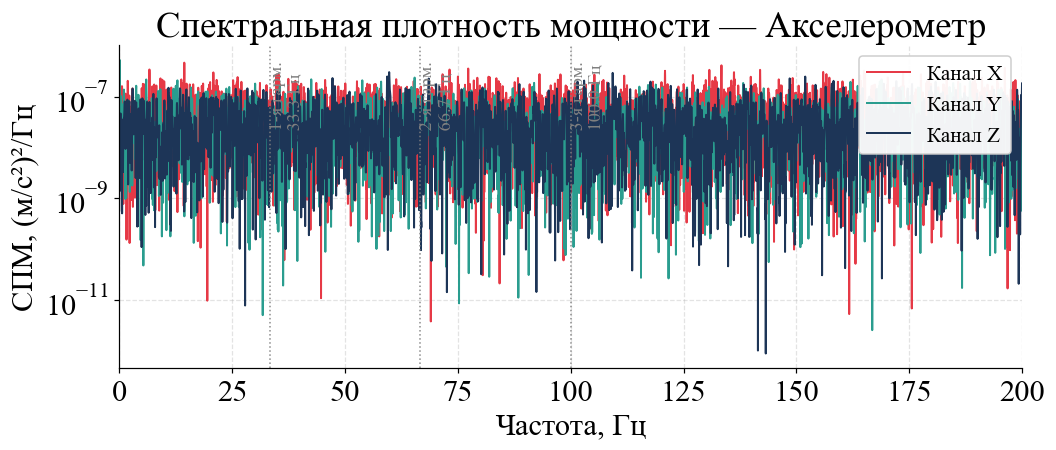

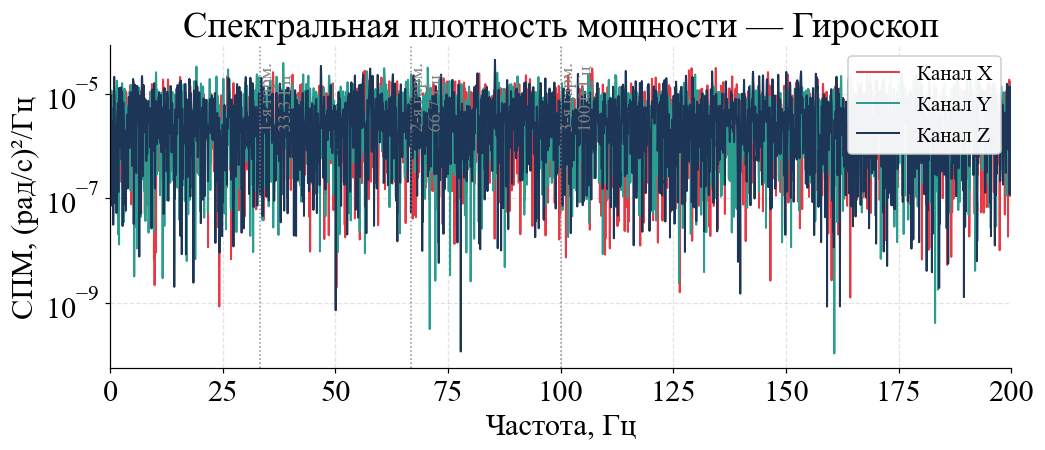

In [4]:
plot_psd(S['imu_time'], S['accel'], fs=400,
         sensor_name='Акселерометр', units='м/с²',
         save_dir=f'{REPORT_DIR}/raw', fname='psd_accel')
_ = plot_psd(S['imu_time'], S['gyro'], fs=400,
         sensor_name='Гироскоп', units='рад/с',
         save_dir=f'{REPORT_DIR}/raw', fname='psd_gyro')

# plot_psd(imu_time, accel_vib, fs=400,
#          sensor_name='Акселерометр', units='м/с²',
#          save_dir=REPORT_DIR, fname='psd_accel')
# _ = plot_psd(imu_time, gyro_vib, fs=400,
#          sensor_name='Гироскоп', units='рад/с',
#          save_dir=REPORT_DIR, fname='psd_gyro')

# Спектрограмма Z-оси акселерометра (там вибрация самая сильная)
# _ = plot_spectrogram_2d(imu_time, accel_vib[:, 2], fs=400,
#                     channel_name='Z', sensor_name='Акселерометр',
#                     save_dir=REPORT_DIR)
# _ = plot_spectrogram_3d(imu_time, accel_vib[:, 2], fs=400,
#                     channel_name='Z', sensor_name='акселерометра',
#                     save_dir=REPORT_DIR)

Девиация Аллана (не работает)

In [ ]:
# from AllanDev import test_allan
# from visualization import load_data, plot_allan_simulated

# sim_Allan = test_allan('generated_data/90_AllanDev')
# data_Allan = load_data('generated_data/90_AllanDev')

# plot_allan_simulated(data_Allan['gyro'], data_Allan['accel'], fs=400,
#                      save_dir=REPORT_DIR)

Глава 1) Оценка ориентации

БИНС с фильтром Маджвика

In [ ]:
sins_madg = make_sins('madgwick', fs=400.0, beta=0.03,
                      init_pos_ned=ref_pos_ned[0],
                      init_vel_ned=ref_vel_ned[0],
                      init_quat=q0, lat0_deg=np.rad2deg(lat0))
# Q_m, v_m, p_m, eul_m = sins_madg.run(accel_vib, gyro_vib)
Q_m, v_m, p_m, eul_m = sins_madg.run(accel_std, gyro_std)

# est = {'euler': eul_est, 'vel': v_est, 'pos': p_est, 'quat': Q}
# ref = {'euler': ref_euler_ned, 'vel': ref_vel_ned, 'pos': ref_pos_ned}

_ = plot_trajectory_3d(ref_pos_ned, p_m, save_dir=f'{REPORT_DIR}/madgwick')
_ = plot_velocity_ned(imu_time, ref_vel_ned, v_m, save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_m, save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_position_error(imu_time, p_m, ref_pos_ned, save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_attitude_error(imu_time, eul_m, ref_euler_ned, save_dir=f'{REPORT_DIR}/madgwick')

БИНС с фильтром Махони

In [ ]:
sins_mah = make_sins('mahony', fs=400.0, k_P=0.1, k_I=0.001,
                     init_pos_ned=ref_pos_ned[0],
                     init_vel_ned=ref_vel_ned[0],
                     init_quat=q0, lat0_deg=np.rad2deg(lat0))
# Q_h, v_h, p_h, eul_h = sins_mah.run(accel_vib, gyro_vib)
Q_h, v_h, p_h, eul_h = sins_mah.run(accel_std, gyro_std)

_ = plot_trajectory_3d(ref_pos_ned, p_h, save_dir=f'{REPORT_DIR}/mahony')
_ = plot_velocity_ned(imu_time, ref_vel_ned, v_h, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_h, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_position_error(imu_time, p_h, ref_pos_ned, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_attitude_error(imu_time, eul_h, ref_euler_ned, save_dir=f'{REPORT_DIR}/mahony')

Параметрический анализ β для фильтра Маджвика

In [ ]:
print("Свип параметра β...")
# beta_values = [0.005, 0.02, 0.05, 0.1, 0.3, 1.0]
beta_values = [1, 0.25, 0.1, 0.05, 0.02, 0.005]
beta_results = {}

for b in beta_values:
    sins_b = make_sins('madgwick', fs=400.0, beta=b,
                       init_pos_ned=ref_pos_ned[0],
                       init_vel_ned=ref_vel_ned[0],
                       init_quat=q0, lat0_deg=data['ref_pos'][0, 0])
    _, _, _, eul_b = sins_b.run(accel_vib, gyro_vib)
    beta_results[b] = eul_b
    print(f"  β = {b:.3f} готово")

plot_beta_sweep(time_imu, beta_results, ref_euler_ned,
                save_dir=f'{REPORT_DIR}/beta_sweep')

Глава 2) Схемы комплексирования на ФК

EKF

In [ ]:
ekf = InsGnssEKF(
    lat0_rad=lat0, fs_imu=400.0, fs_gps=10.0,
    sigma_a_n=sigma_a_n, sigma_g_n=sigma_g_n,
    sigma_ba=sigma_ba, sigma_bg=sigma_bg,
    sigma_gps_pos=sigma_gps_pos, sigma_gps_vel=sigma_gps_vel,
    init_r=ref_pos_ned[0], init_v=ref_vel_ned[0],
    init_q=q0,
)

N = len(imu_time)
p_ekf  = np.zeros((N, 3))
v_ekf  = np.zeros((N, 3))
eul_ekf = np.zeros((N, 3))

g_ptr = 0
for k in range(N):
    ekf.predict(accel_std[k], gyro_std[k])
    if g_ptr < len(gps_idx) and k == gps_idx[g_ptr]:
        ekf.update_gnss(gps_pos_ned[g_ptr], gps_vel_ned[g_ptr])
        g_ptr += 1
    p_ekf[k]   = ekf.r
    v_ekf[k]   = ekf.v
    eul_ekf[k] = ekf.euler_zyx_deg

_ = plot_trajectory_3d(ref_pos_ned, p_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_position_error(imu_time, p_ekf, ref_pos_ned, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_attitude_error(imu_time, eul_ekf, ref_euler_ned, save_dir=f'{REPORT_DIR}/ekf')

UKF

In [ ]:
ukf = InsGnssUKF(
    lat0_rad=lat0, fs_imu=400.0, fs_gps=10.0,
    sigma_a_n=sigma_a_n, sigma_g_n=sigma_g_n,
    sigma_ba=sigma_ba, sigma_bg=sigma_bg,
    init_r=ref_pos_ned[0], init_v=ref_vel_ned[0],
    init_q=q0,
)

p_ukf, v_ukf, eul_ukf = np.zeros((N, 3)), np.zeros((N, 3)), np.zeros((N, 3))
g_ptr = 0
for k in range(N):
    ukf.predict(accel_std[k], gyro_std[k])
    if g_ptr < len(gps_idx) and k == gps_idx[g_ptr]:
        ukf.update_gnss(gps_pos_ned[g_ptr], gps_vel_ned[g_ptr])
        g_ptr += 1
    p_ukf[k]   = ukf.r
    v_ukf[k]   = ukf.v
    eul_ukf[k] = ukf.euler_zyx_deg
    
_ = plot_trajectory_3d(ref_pos_ned, p_ekf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_ekf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_ekf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_position_error(imu_time, p_ekf, ref_pos_ned, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_attitude_error(imu_time, eul_ekf, ref_euler_ned, save_dir=f'{REPORT_DIR}/ukf')

Глава 3) Комплексирование на базе FGO

FGO

Этап 3) Сравниваем